<a href="https://colab.research.google.com/github/melihaslan233-glitch/Water-Quality-data-/blob/main/waterqualitySAMSUNG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [111]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/water_potability.csv')

df.head() # gives us first five rows

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [112]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


# Missing Values

In [113]:
df.isnull().sum() # Checking for missing values

,0
ph,491
Hardness,0
Solids,0
Chloramines,0
Sulfate,781
Conductivity,0
Organic_carbon,0
Trihalomethanes,162
Turbidity,0
Potability,0


In [114]:
# printing missing values
print(f"\nTotal missing: {df.isnull().sum().sum()} values")


Total missing: 1434 values



# Filling missing values with column mean (excluding potability)


In [115]:
features = df.drop(columns=['Potability']).columns
df[features] = df[features].fillna(df[features].mean())

In [116]:
# Checking missing values
print("Missing values after filling with mean")
print(df.isnull().sum())

Missing values after filling with mean
ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64


# Plotting potability

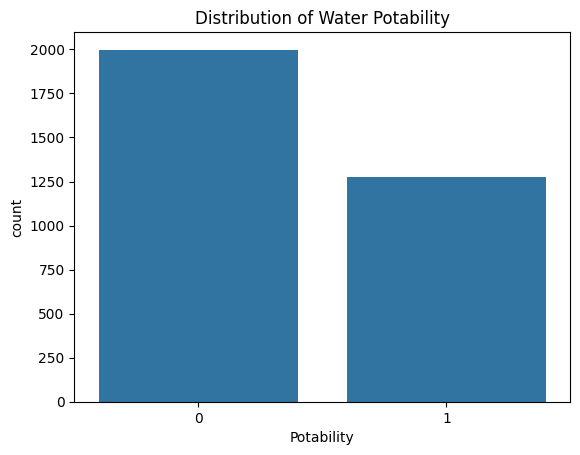

In [117]:
sns.countplot(x='Potability', data=df)
plt.title("Distribution of Water Potability")
plt.show()

# Most of the water is not drinkable

# Correlation Matrix of Potability

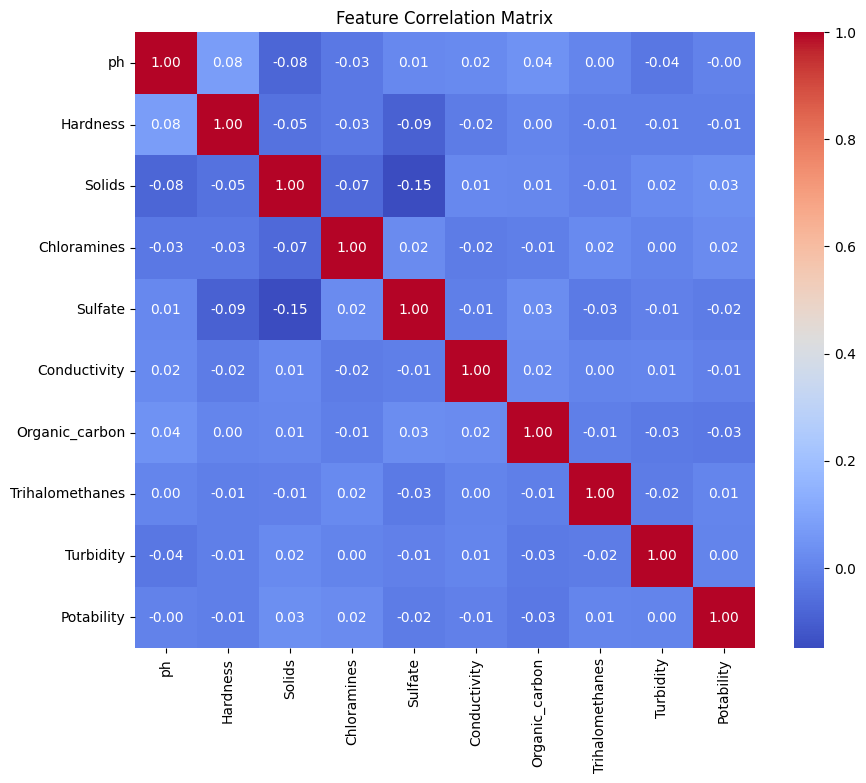

In [118]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt='.2f',cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()
# fmt='.2f' Stops the numbers two decimal places